In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    "Listings.csv",
    encoding="latin1",
    low_memory=False
)

# Basic Information
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(30))

Shape: (279712, 33)

Columns:
['listing_id', 'name', 'host_id', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'district', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable']

Data Types:
listing_id                       int64
name                               str
host_id                          int64
host_since                         str
host_location                      str
host_response_time                 str
host_response_rate             float64
host_acceptance_rate           float64
host_is_superhost             

In [17]:
df = df.copy()

# Convert t/f to 1/0
binary_cols = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable'
]

for col in binary_cols:
    df[col] = df[col].map({'t':1,'f':0})

# Fill bedrooms
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

# Fill review scores
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

for col in review_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill response rates
df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())

In [20]:
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(20))
df.info()

(279712, 33)
district                       242700
host_response_time             128782
host_location                     840
name                              175
host_has_profile_pic              165
host_since                        165
host_is_superhost                 165
host_total_listings_count         165
host_identity_verified            165
review_scores_cleanliness           0
minimum_nights                      0
maximum_nights                      0
review_scores_rating                0
review_scores_accuracy              0
listing_id                          0
review_scores_checkin               0
amenities                           0
review_scores_communication         0
review_scores_location              0
review_scores_value                 0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   ----

In [33]:


#renaming small missing values
df['host_is_superhost'] = df['host_is_superhost'].fillna(0)

df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna(1)

df['host_identity_verified'] = df['host_identity_verified'].fillna(0)

df['host_total_listings_count'] = df['host_total_listings_count'].fillna(
    df['host_total_listings_count'].median()
)

#drop unnecessary columns

df.drop(
    columns=[
        'listing_id',
        'name',
        'host_id',
        'host_since',
        'host_location',
        'host_response_time'
    ],
    inplace=True,
    errors='ignore'

)

In [34]:
print(df.shape)
print(df.columns.tolist())

(279712, 26)
['host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable']


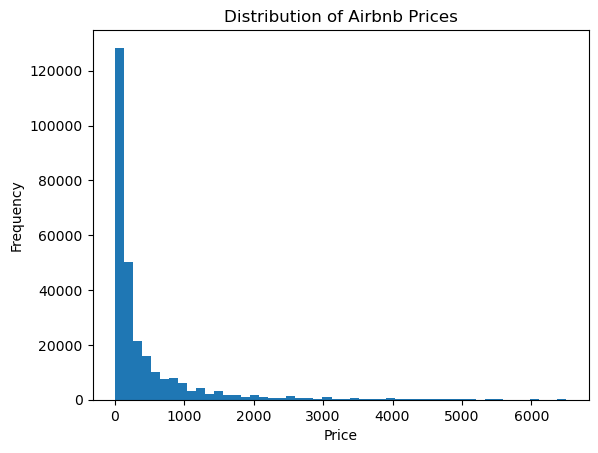

In [96]:
#Price Distribution
plt.hist(df['price'], bins=50)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("Price_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

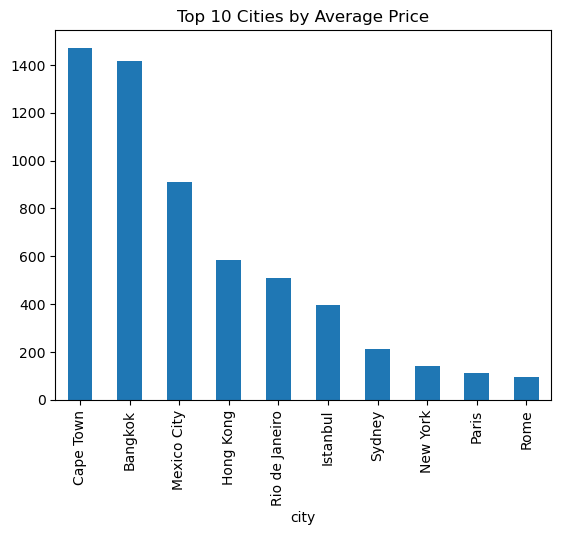

In [97]:
#Average Price by city
city_price = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)
city_price.plot(kind='bar')
plt.title("Top 10 Cities by Average Price")
plt.savefig("Average_price_by_city.png",dpi=300,bbox_inches="tight")
plt.show()

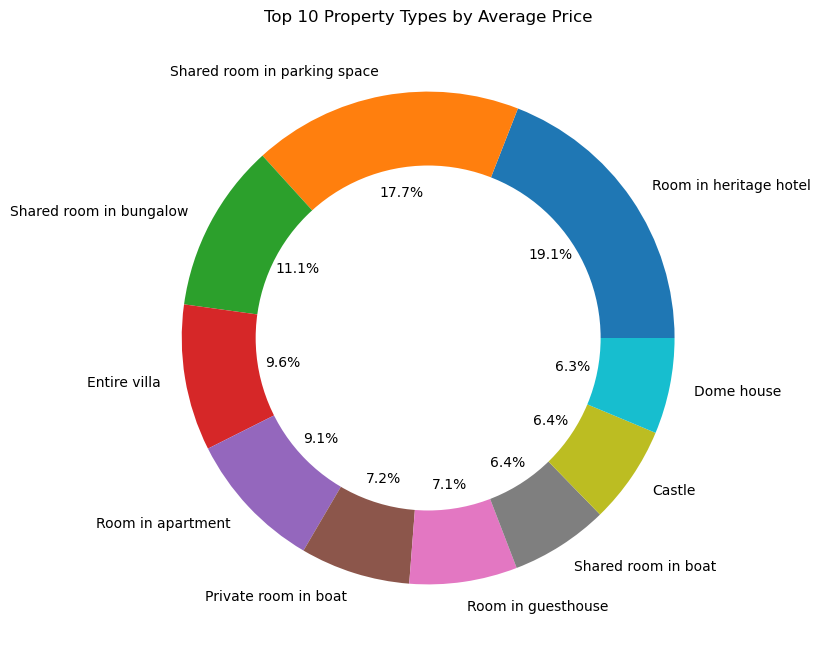

In [98]:
#Property Type vs Price
prop_price = df.groupby('property_type')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(
    prop_price,
    labels=prop_price.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Top 10 Property Types by Average Price")

plt.savefig("property_type_by_average_price.png",dpi=300,bbox_inches="tight")

plt.show()

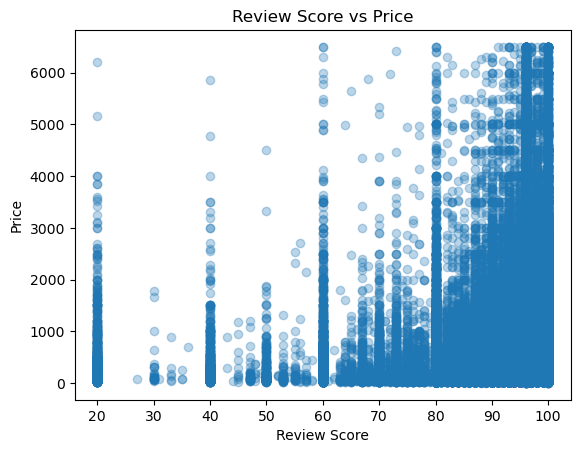

In [105]:
#Review Score vs Price
plt.scatter(
    df['review_scores_rating'],
    df['price'],
    alpha=0.3
)
plt.xlabel("Review Score")
plt.ylabel("Price")
plt.title("Review Score vs Price")
plt.savefig("Review Score vs Price.png",dpi=300,bbox_inches="tight")
plt.show()

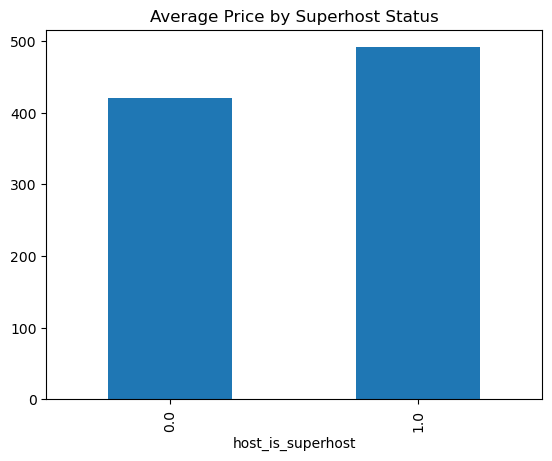

In [106]:
#Superhost vs Price
df.groupby('host_is_superhost')['price'].mean().plot(kind='bar')
plt.title("Average Price by Superhost Status")
plt.savefig("Average Price by Superhost Status.png",dpi=300,bbox_inches="tight")
plt.show()

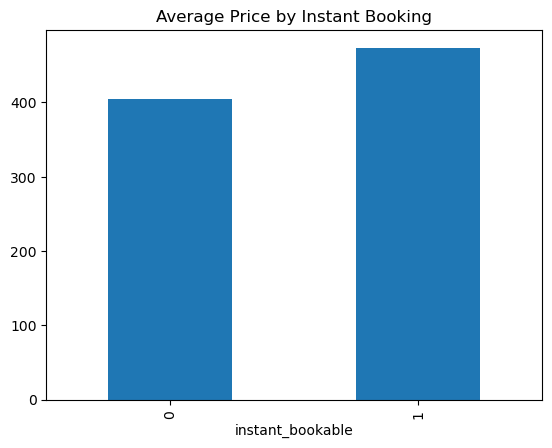

In [107]:
#Instant Booking vs Price
df.groupby('instant_bookable')['price'].mean().plot(kind='bar')
plt.title("Average Price by Instant Booking")
plt.savefig("Average Price by Instant Booking",dpi=300,bbox_inches="tight")
plt.show()


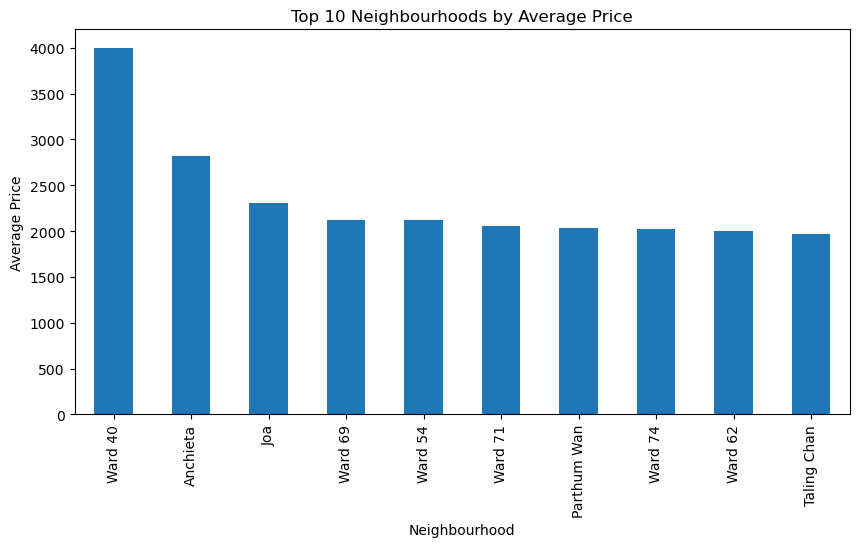

In [112]:
import matplotlib.pyplot as plt

neighbourhood_price = (
    df.groupby('neighbourhood')['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
neighbourhood_price.plot(kind='bar')

plt.title("Top 10 Neighbourhoods by Average Price")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price")


plt.savefig("Top 10 Neighbourhoods by Average Price.png",dpi=300,bbox_inches="tight")
plt.show()

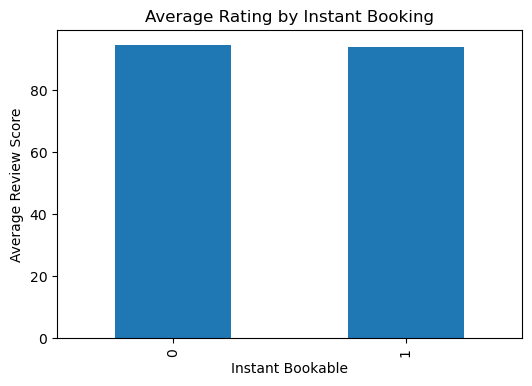

In [113]:
rating_booking = (
    df.groupby('instant_bookable')
      ['review_scores_rating']
      .mean()
)

plt.figure(figsize=(6,4))
rating_booking.plot(kind='bar')

plt.title("Average Rating by Instant Booking")
plt.xlabel("Instant Bookable")
plt.ylabel("Average Review Score")

plt.savefig("Average Rating by Instant Booking.png",dpi=300,bbox_inches="tight")
plt.show()

         Average Price
Wifi        428.148733
Kitchen     421.965861
TV          484.630366
Washer      452.609552
Heating     291.335699


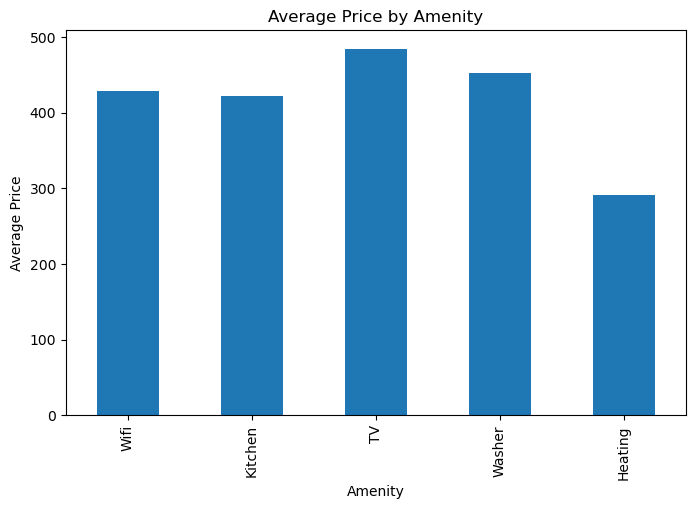

In [114]:
#Create Amenity Indicators
df['wifi'] = df['amenities'].str.contains('Wifi', case=False, na=False)

df['kitchen'] = df['amenities'].str.contains('Kitchen', case=False, na=False)

df['tv'] = df['amenities'].str.contains('TV', case=False, na=False)

df['washer'] = df['amenities'].str.contains('Washer', case=False, na=False)

df['heating'] = df['amenities'].str.contains('Heating', case=False, na=False)

#Compare Average Prices
amenity_prices = pd.DataFrame({
    'Wifi': df.groupby('wifi')['price'].mean()[True],
    'Kitchen': df.groupby('kitchen')['price'].mean()[True],
    'TV': df.groupby('tv')['price'].mean()[True],
    'Washer': df.groupby('washer')['price'].mean()[True],
    'Heating': df.groupby('heating')['price'].mean()[True]
}, index=['Average Price'])

print(amenity_prices.T)

amenity_prices.T.plot(
    kind='bar',
    legend=False,
    figsize=(8,5)
)

plt.title("Average Price by Amenity")
plt.xlabel("Amenity")
plt.ylabel("Average Price")


plt.savefig("Average Price by Amenity.png",dpi=300,bbox_inches="tight")
plt.show()

In [63]:
print(df['price'].describe())

count    279712.000000
mean        608.792737
std        3441.826611
min           0.000000
25%          75.000000
50%         150.000000
75%         474.000000
max      625216.000000
Name: price, dtype: float64


In [64]:
print(df['price'].quantile([0.90,0.95,0.99,0.999]))

0.900     1200.000
0.950     2000.000
0.990     6500.000
0.999    32177.917
Name: price, dtype: float64


In [65]:
upper_limit = df['price'].quantile(0.99)

df = df[df['price'] <= upper_limit]

df = df[df['price'] > 0]

In [66]:
print(df['price'].describe())

count    276874.000000
mean        433.198368
std         736.241305
min           1.000000
25%          75.000000
50%         150.000000
75%         450.000000
max        6500.000000
Name: price, dtype: float64


In [67]:
df['price'].quantile([0.90,0.95,0.99,0.999])

0.900    1100.0
0.950    1799.0
0.990    4000.0
0.999    6000.0
Name: price, dtype: float64

In [69]:
upper_limit = df['price'].quantile(0.99)

df_ml = df[
    (df['price'] > 0) &
    (df['price'] <= upper_limit)
].copy()

print(df_ml.shape)

(274349, 26)


In [70]:
#Ml for price prediction 
#feature x
features = [
    'city',
    'property_type',
    'room_type',
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'maximum_nights',
    'review_scores_rating',
    'host_is_superhost',
    'instant_bookable',
    'host_response_rate',
    'host_acceptance_rate'
]
#Target Y
target = 'price'

#Create X and y
X = df_ml[features]

y = df_ml[target]

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(df_ml.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(274349, 26)
(219479, 12)
(54870, 12)
(219479,)
(54870,)


In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'city',
    'property_type',
    'room_type'
]

numeric_features = [
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'maximum_nights',
    'review_scores_rating',
    'host_is_superhost',
    'instant_bookable',
    'host_response_rate',
    'host_acceptance_rate'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [76]:
#LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 381.96656312746103
RMSE: 585.1403572846965
R2 Score: -2.772415010454665e-06


In [77]:
#DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE: 179.71919695587525
RMSE: 362.0262220418479
R2 Score: 0.6172094961909578


In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 168.4280251498433
RMSE: 351.2107502822762
R2 Score: 0.639739455864172


In [81]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'R2': [r2_lr, r2_dt, r2_rf]
})

print(results)

               Model         MAE        RMSE        R2
0  Linear Regression  381.966563  585.140357 -0.000003
1      Decision Tree  179.719197  362.026222  0.617209
2      Random Forest  168.428025  351.210750  0.639739


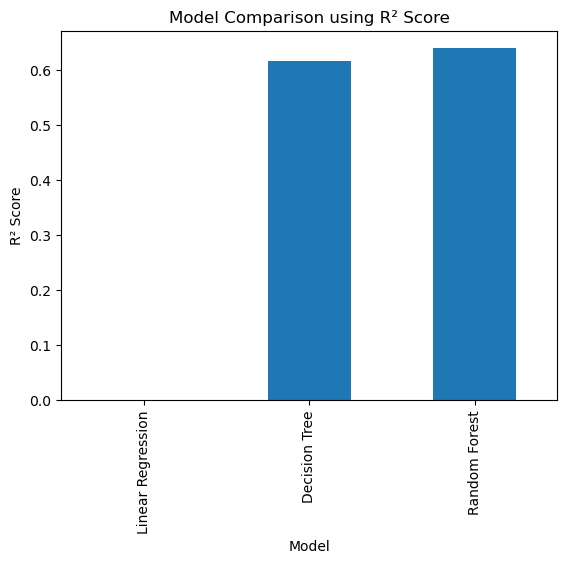

In [85]:
import matplotlib.pyplot as plt

results.set_index('Model')['R2'].plot(kind='bar')

plt.title('Model Comparison using R² Score')
plt.ylabel('R² Score')

plt.savefig(
    'Model_Comparison_R2.png',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig("Model Comparison using R² Score.png",dpi=300,bbox_inches="tight")
plt.show()

In [83]:
import pandas as pd

# Get feature names after one-hot encoding
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get importance values
importances = rf_model.named_steps['model'].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

                                       Feature  Importance
1                          cat__city_Cape Town    0.170759
0                            cat__city_Bangkok    0.167809
154                        remainder__bedrooms    0.112111
4                        cat__city_Mexico City    0.080580
153                    remainder__accommodates    0.076682
156                  remainder__maximum_nights    0.050992
161            remainder__host_acceptance_rate    0.050660
155                  remainder__minimum_nights    0.048405
157            remainder__review_scores_rating    0.044465
160              remainder__host_response_rate    0.026572
7                     cat__city_Rio de Janeiro    0.020323
159                remainder__instant_bookable    0.016449
2                          cat__city_Hong Kong    0.013824
3                           cat__city_Istanbul    0.013433
158               remainder__host_is_superhost    0.011220
149                cat__room_type_Entire place    0.0085

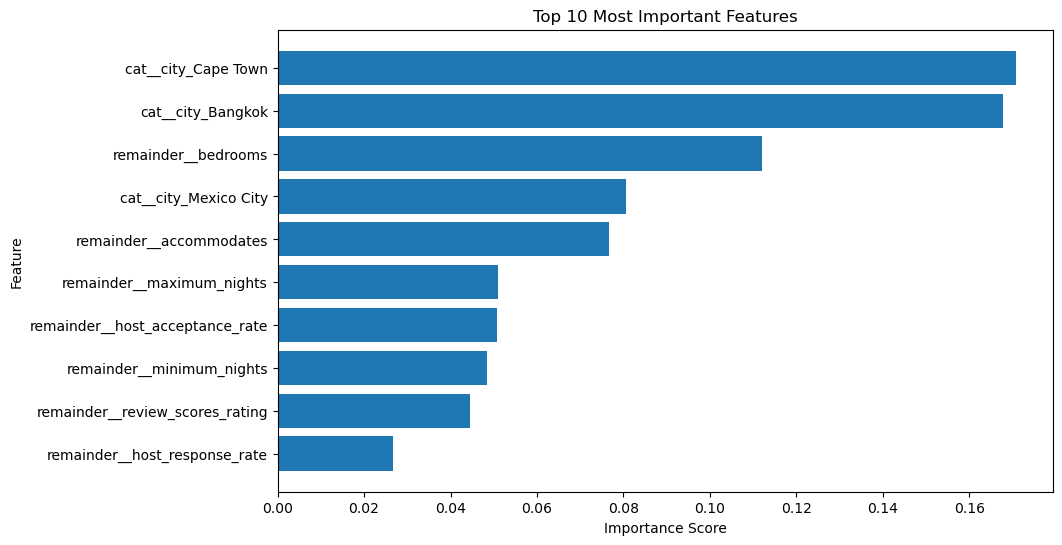

In [86]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.savefig(
    "Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("Top 10 Most Important Features.png",dpi=300,bbox_inches="tight")
plt.show()

In [87]:
df['amenities'].head()

0    ["Heating", "Kitchen", "Washer", "Wifi", "Long...
1    ["Shampoo", "Heating", "Kitchen", "Essentials"...
2    ["Heating", "TV", "Kitchen", "Washer", "Wifi",...
3    ["Heating", "TV", "Kitchen", "Wifi", "Long ter...
4    ["Heating", "TV", "Kitchen", "Essentials", "Ha...
Name: amenities, dtype: str